In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import globals as gl
import os
from myplot import make_yref

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


/tmp/ipykernel_697615/2193071037.py:25: RuntimeWarning: Mean of empty slice.
  force_tmp = force[(dat.cue == cue) & (dat.stimFinger == stimF) & (dat.GoNogo == 'go'), f].mean(axis=0, keepdims=True).squeeze()
/home/ROBARTS/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


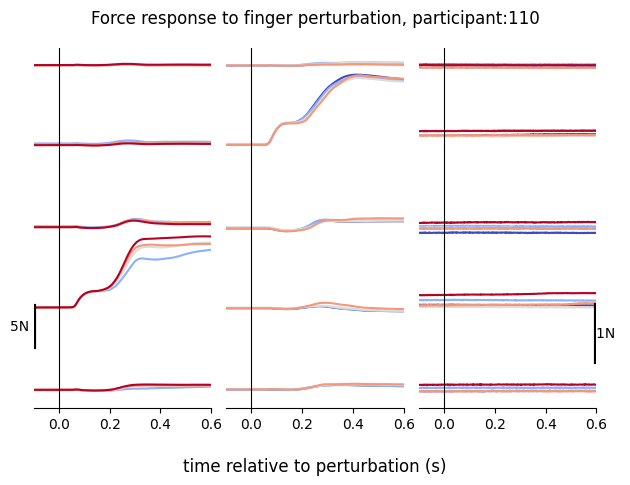

In [15]:
experiment = 'smp2'
sn = 110
vsep_go = 10
vsep_nogo = 1.5

pinfo = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')
runs = pinfo[pinfo['sn']==sn].FuncRuns.reset_index(drop=True)[0].split('.')

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
dat = dat[dat['BN'].astype(str).isin(runs)]

npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_segmented.npz'))
force = npz['data_array']

fig, axs = plt.subplots(ncols=3, sharex=True)

cmap = plt.get_cmap("coolwarm")
colors = [cmap(i) for i in np.linspace(0, 1, force.shape[1])]

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for c, cue in enumerate(gl.cue_code):
    for sf, stimF in enumerate(gl.stimFinger_code):
        for f in range(force.shape[1]):
            force_tmp = force[(dat.cue == cue) & (dat.stimFinger == stimF) & (dat.GoNogo == 'go'), f].mean(axis=0, keepdims=True).squeeze()
            axs[sf].plot(tAx, force_tmp + f * vsep_go, color=colors[c])

axs[0].spines[['top', 'right', 'left']].set_visible(False)
axs[0].axvline(0, ls='-', color='k', lw=.8)
axs[0].set_yticks([])

axs[1].spines[['top', 'right', 'left']].set_visible(False)
axs[1].axvline(0, ls='-', color='k', lw=.8)
axs[1].set_yticks([])

axs[0].set_xlim([-.1, .6])
axs[0].set_ylim([-2, 42])
axs[1].set_ylim([-2, 42])

for c, cue in enumerate(gl.cue_code):
    for f in range(force.shape[1]):
        force_tmp = force[(dat.cue == cue) & (dat.GoNogo == 'nogo'), f].mean(axis=0, keepdims=True).squeeze()
        axs[2].plot(tAx, force_tmp + f * vsep_nogo, color=colors[c])

axs[2].spines[['top', 'right', 'left']].set_visible(False)
axs[2].axvline(0, ls='-', color='k', lw=.8)
axs[2].set_yticks([])

make_yref(axs[0], reference_length=5, pos='left')
make_yref(axs[2], reference_length=1, pos='right')

fig.supxlabel('time relative to perturbation (s)')

fig.suptitle(f'Force response to finger perturbation, participant:{sn}')

fig.tight_layout()

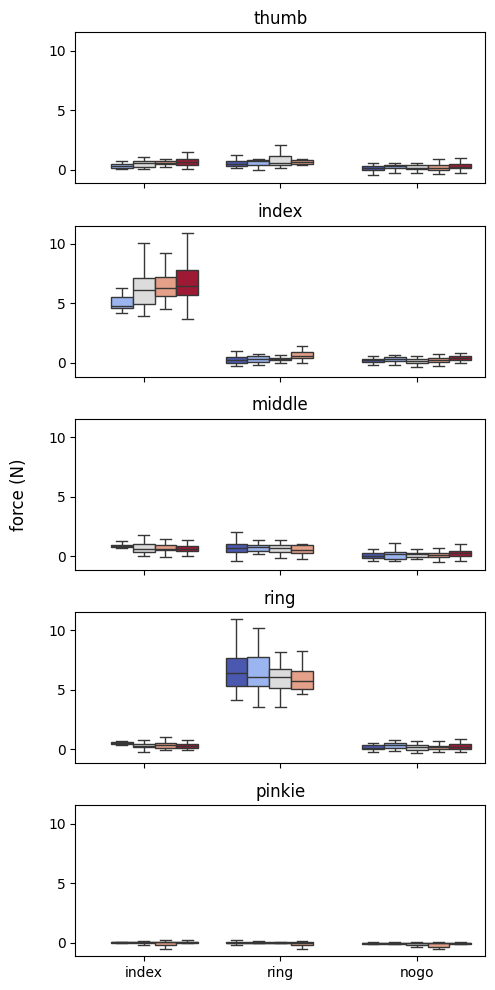

In [18]:
experiment = 'smp2'
sn = 110

force_df = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
force_df['cue'] = force_df['cue'].map(gl.cue_mapping)
force_df['stimFinger'] = force_df['stimFinger'].map(gl.stimFinger_mapping)

fingers = ['thumb', 'index', 'middle', 'ring', 'pinkie']

fig, axs = plt.subplots(len(fingers), sharex=True, sharey=True, figsize=(5, 10))

cmap = plt.get_cmap("coolwarm")
colors = [cmap(i) for i in np.linspace(0, 1, 5)]

for f, finger in enumerate(fingers):

    sns.boxplot(x='stimFinger', y=finger, ax=axs[f], hue='cue',data=force_df, hue_order=list(gl.cue_mapping.values()), order=list(gl.stimFinger_mapping.values()), showfliers=False, palette=colors, legend=False)

    axs[f].set_xlabel('')
    axs[f].set_ylabel('')
    axs[f].set_title(finger)

fig.supylabel('force (N)')
fig.tight_layout()